In [1]:
import numpy as np
import scipy as sp

In [2]:
def f_cstr(t, y, Da, beta, B):
    """Time derivatives of the CSTR model."""
    x1, x2 = y
    dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
    dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2

    return [dx1dt, dx2dt]


def get_pars(Da: np.float=0.25, B: np.float=11, beta: np.float=3):
#     B = 22.0
#     beta = 3.0
    

    pars = Da, beta, B
    return pars

def ODE(t, y, Da = 0.25):
    Da, beta, B = get_pars(Da)
    return f_cstr(t, y, Da, beta, B)

def ODE_ss(y, Da = 0.25):
    Da, beta, B = get_pars(Da)
    return f_cstr(0, y, Da, beta, B)

In [3]:
from scipy.optimize import fsolve

Da_arr = np.linspace(0.2,0.5,100)
roots = []
root = [0.5, 3]

for i in range(len(Da_arr)):
    root = fsolve(ODE_ss, root, args=(Da_arr[i]))
    roots.append(root)
    
roots = np.array(roots)

Text(0, 0.5, '$x_2$')

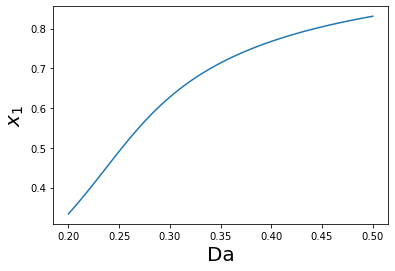

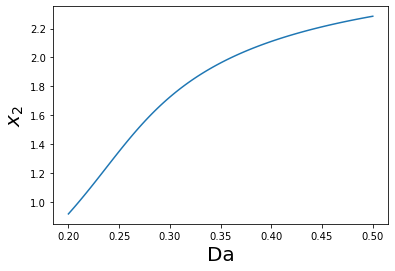

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(Da_arr,roots[:,0])
plt.xlabel(r'Da', fontsize=20)
plt.ylabel(r'$x_1$', fontsize=20)

plt.figure()
plt.plot(Da_arr,roots[:,1])
plt.xlabel(r'Da', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)


In [5]:
from scipy.integrate import solve_ivp

def ODE_cstr(t, y, Da, beta, B, C):
    """Time derivatives of the CSTR model."""
    x1, x2 = y
    dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
    dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2

    return [dx1dt, dx2dt]

def ODE_Event(t, y, Da, beta, B, C):
    x1, x2 = y
    
    condition = (x1 - C)
    
#     print('====Event====')
#     print(t)
#     print(condition)
#     print(x1)
#     print(C)
#     print('=============')
#     print('event')
#     print(t)
#     print(x1)
#     print(C)
    
    return (x1-C)
#     if t>0.1:
#         return (x1 - C)
#     else: return 100
    

def ODE_Bifurc(y, Da=0.35, x10=0.7):
    x2, T = y
    pars = *get_pars(Da), x10
    
#     event = ODE_Event
#     event.terminal = True
    
    y0 = [x10, x2]
    
    sol = solve_ivp(ODE_cstr, y0=y0, t_span=[0, 0.1],
                    args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    y_init = sol.y[:,-1]
#     print('init values')
#     print(y0)
#     print(y_init)
    
    sol = solve_ivp(ODE_cstr, y0=y_init, t_span=[0.1, T],
                    args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
#     plt.figure()
#     plt.plot(sol.t, sol.y[0,:])
#     plt.plot(sol.t, sol.y[1,:])
    
    T_out = sol.t[-1]
    x1_out = sol.y[0,-1]
    x2_out = sol.y[1,-1]

    
#     return (x2-x2_out)
    return (x10-x1_out), (x2-x2_out)


In [6]:
from scipy.optimize import least_squares

i=58

Da = Da_arr[i]
print('Da is: ' + str(Da))

x10 = roots[i,0]+0.05
y0 = [roots[i,1], 2]

root = ODE_Bifurc(y0, Da=Da)
print(root)

print('=======================')
y, infodict, ier, mesg = fsolve(ODE_Bifurc, y0, args=(Da_arr[i], x10), full_output=True)
# result = least_squares(ODE_Bifurc, y0, args=(Da_arr[i], roots[i,0]))
# y = result.x

print(y)
print(ODE_Bifurc(y, Da_arr[i], x10))

print('=======================')
print(infodict)
print(ier)
print(mesg)
# print(result.status)
# print(result.message)
# print(result.success)

Da is: 0.37575757575757573
(0.038929986477789225, 0.3415608052046586)
[1.86934393 2.23010119]
(5.966338534335591e-13, 3.4574565432876625e-12)
{'nfev': 23, 'fjac': array([[-0.98835477,  0.15216719],
       [-0.15216719, -0.98835477]]), 'r': array([ 0.07689394,  0.00912988, -1.97947093]), 'qtf': array([2.75999386e-11, 2.08706437e-09]), 'fvec': array([5.96633853e-13, 3.45745654e-12])}
1
The solution converged.


Da is: 0.37575757575757573
[0.7941300653020906, 1.8693439335374031]


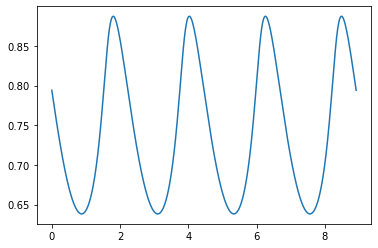

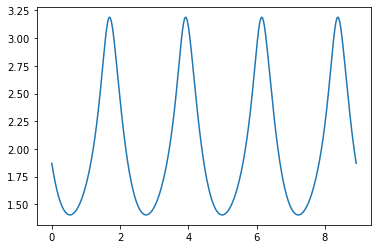

In [7]:
event = ODE_Event
# event.terminal = True

Da = Da_arr[i]

print('Da is: ' + str(Da))

# y0 = [roots[i,0], roots[i,1]+0.1]
# y0 = [0.42689356+0.2, 1.17333033+0.2]
# y0 = [y[0], y[1]]
y0_int = [x10, y[0]]
print(y0_int)
# y0 = [0.8980617, 3.02548923]

pars = get_pars(Da)

def f_cstr(t, y2, Da, beta, B):
    """Time derivatives of the CSTR model."""
    x1, x2 = y2
    dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
    dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2

    return [dx1dt, dx2dt]

def new_event(t, y2, Da, beta, B):
    x1, x2 = y2
    return (x1 - y0[0])

t_eval = np.linspace(0, y[1]*4, 1000)
sol = solve_ivp(f_cstr, y0=y0_int, t_span=[0, t_eval[-1]],
                    args=pars, t_eval=t_eval,
                    rtol=1e-5, atol=1e-8, events=new_event)

plt.figure()
plt.plot(sol.t, sol.y[0,:])

plt.figure()
plt.plot(sol.t, sol.y[1,:])

In [8]:
from jax import jacfwd, jacrev
import jax.numpy as jnp

def myf_cstr(t, y, Da, beta, B):
    """Time derivatives of the CSTR model."""
    x1, x2 = y
    dx1dt = -x1 + Da * (1-x1) * jnp.exp(x2)
    dx2dt = -x2 + B * Da * (1-x1) * jnp.exp(x2) - beta * x2

    return [dx1dt, dx2dt]

i=26
Da = Da_arr[i]
print("Da =:" + str(Da))
pars = get_pars(Da)

myf = lambda y: myf_cstr(0, y, *pars)
myroots = [roots[i,0], roots[i,1]]

print(myroots)
print(pars)
J = jacfwd(myf)(myroots)
print(np.asarray(J))

w, v = np.linalg.eig(J)
print(w)
print(np.any(w.real>0))

Da =:0.2787878787878788
[0.5762392114586694, 1.5846578315113409]
(0.2787878787878788, 3, 11)
[[ -2.3598218    0.57623917]
 [-14.958039     2.3386302 ]]
[-0.0105958+1.7608366j -0.0105958-1.7608366j]
False


In [9]:
import torch

def myf_cstr_torch(t, y, Da, beta, B):
    """Time derivatives of the CSTR model."""
    x1, x2 = y
    dx1dt = -x1 + Da * (1-x1) * torch.exp(x2)
    dx2dt = -x2 + B * Da * (1-x1) * torch.exp(x2) - beta * x2

    return torch.stack((dx1dt, dx2dt))

i=72
Da = Da_arr[i]
print("Da =:" + str(Da))
Da, beta, B = get_pars(Da)
pars = torch.tensor(Da), torch.tensor(beta), torch.tensor(B)

myf = lambda y: myf_cstr_torch(0, y, *pars)
myroots = torch.tensor([roots[i,0], roots[i,1]])


print(myf(myroots))

print(myroots)
J = torch.autograd.functional.jacobian(myf, myroots, strict=True)

print(J.detach().cpu().numpy())

w, v = np.linalg.eig(J)
print(w)
print(np.any(w.real>0))

Da =:0.4181818181818182
tensor([-2.2204e-16, -3.5527e-15], dtype=torch.float64)
tensor([0.7824, 2.1516], dtype=torch.float64)
[[ -4.59594946   0.7824171 ]
 [-39.55544411   4.60658813]]
[0.00531933+3.12684848j 0.00531933-3.12684848j]
True
